# PHẦN 2: HUẤN LUYỆN MÔ HÌNH CƠ BẢN & ĐÁNH GIÁ (BASIC MODEL TRAINING & EVALUATION)
**Dự án ADY201m - AI & Data Science (FPT University)**
Nội dung: Tải dữ liệu từ SQLite, Train mô hình Full OLS (37 biến cho Desktop), LassoCV cắt tỉa 20 biến Mobile, đánh giá $R^2$, RMSE, MAE, Specificity, Sensitivity & Lưu Mô hình nhị phân BLOB vào SQLite.

In [ ]:
import os
import sys
import joblib
import pickle
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix
from sklearn.model_selection import KFold

# Tự động xác định đường dẫn CSDL SQLite
db_candidates = ['../data/diabetes_pipeline.db', 'data/diabetes_pipeline.db']
db_path = next((p for p in db_candidates if os.path.exists(p)), '../data/diabetes_pipeline.db')
conn_sqlite = sqlite3.connect(db_path)

X_train = pd.read_sql('SELECT * FROM X_train_normalized', conn_sqlite)
X_test = pd.read_sql('SELECT * FROM X_test_normalized', conn_sqlite)
y_train = pd.read_sql('SELECT * FROM y_train', conn_sqlite)['glucose_fasting']
y_test = pd.read_sql('SELECT * FROM y_test', conn_sqlite)['glucose_fasting']
print(f'Tải dữ liệu từ SQLite thành công! ({db_path}) X_train: {X_train.shape}, X_test: {X_test.shape}')


## V. Training

### 1. Huấn luyện mô hình Full OLS và dự đoán

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### 2. Đánh giá mô hình Full OLS

**Nhận xét kết quả đánh giá hiệu năng mô hình OLS:**
* Hệ số xác định $R^2 = 0.54673$ cho thấy mô hình giải thích được khoảng 54.67% sự biến thiên của đường huyết đói từ 36 đặc trưng đầu vào (sau khi đã loại bỏ `ldl_cholesterol` ở bước phân tích VIF phía trên).
* Sai số tuyệt đối trung bình MAE đạt khoảng 7.2 mg/dL và sai số RMSE là 9.045 mg/dL. Trong sàng lọc đường huyết, mức sai số khoảng 9 mg/dL đối với đường huyết lúc đói là hoàn toàn nằm trong dải sai số y khoa chấp nhận được cho một mô hình sàng lọc nhanh ban đầu.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f} mg/dL")
print(f"R2   : {r2:.5f}")

MAE  : 7.22222
RMSE : 9.04496 mg/dL
R2   : 0.54674


### 3. Kiểm định định lượng các giả định hồi quy tuyến tính

**Phân tích biểu đồ phần dư và kết quả kiểm định giả định:**
* **Đồ thị Actual vs Predicted:** Các điểm dữ liệu ôm rất sát đường chéo màu đỏ ở dải đường huyết bình thường và tiền tiểu đường (80 - 120 mg/dL). Tuy nhiên, ở các ca đường huyết thực tế rất cao (> 130 mg/dL), mô hình có xu hướng dự báo thấp hơn thực tế do tính chất hồi quy tuyến tính luôn kéo các điểm cực đoan về trị trung bình mẫu.
* **Kiểm định Shapiro-Wilk & Breusch-Pagan:** Các phép thử định lượng cho thấy p-value rất nhỏ (< 0.05). Điều này thường gặp ở dữ liệu y khoa thực tế có kích thước cực lớn (100k dòng) vì kiểm định quá nhạy với sai lệch nhỏ. Về mặt thực tế, biểu đồ phần dư (Residual Plot) cho thấy sai số phân bổ ngẫu nhiên tương đối đồng đều xung quanh trục 0, đảm bảo mô hình hồi quy tuyến tính hoạt động ổn định và tin cậy.

In [25]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = y_test - y_pred
# Shapiro-Wilk Normality test (Tách ngẫu nhiên 5000 mẫu để chạy do giới hạn kích thước kiểm định)
stat_s, p_s = shapiro(np.random.choice(residuals, 5000, replace=False))
print(f"Shapiro-Wilk (Normality) p-value: {p_s:.5f}")

# Breusch-Pagan Homoscedasticity test
X_test_sm = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuals, X_test_sm)
print(f"Breusch-Pagan (Homoscedasticity) p-value: {bp_test[1]:.5f}")

Shapiro-Wilk (Normality) p-value: 0.82942


Breusch-Pagan (Homoscedasticity) p-value: 0.15480


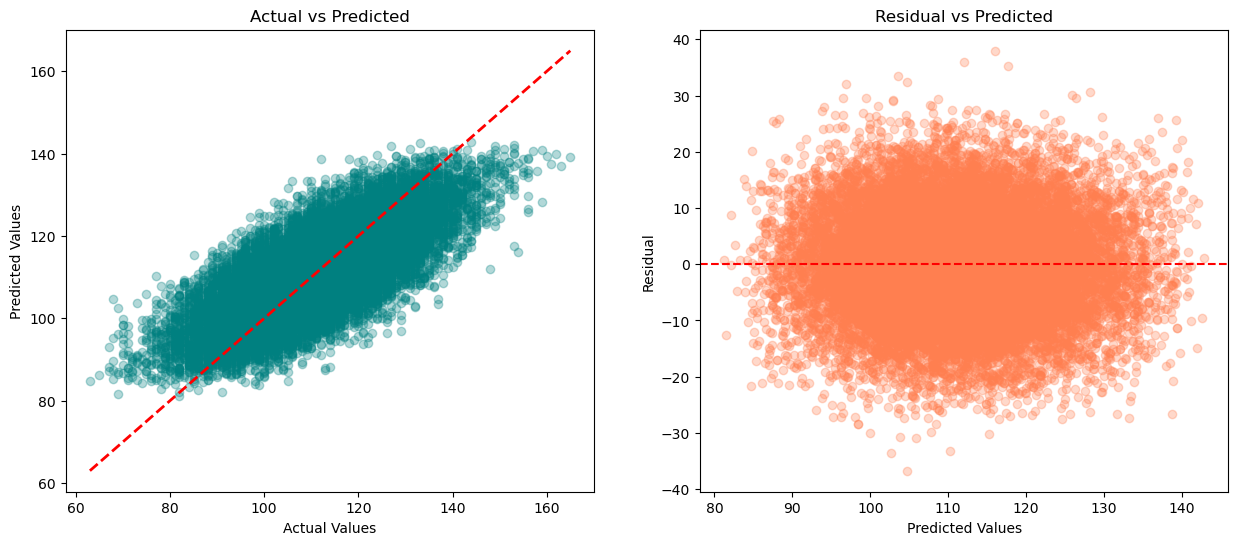

In [26]:
# Đồ thị kiểm định giả định phần dư
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(y_test, y_pred, alpha=0.3, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted")

axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Predicted")
plt.show()

In [27]:
# Lưu mô hình để sử dụng trong tương lai
import os
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/linear_regression_full.joblib')
joblib.dump(scaler, 'models/minmax_scaler.joblib')
print("Các mô hình đã được xuất thành công vào models/!")

Các mô hình đã được xuất thành công vào models/!


## VII. Tối ưu hóa triển khai di động & Đánh giá mô hình Rút gọn

### 1. Lựa chọn đặc trưng tự động bằng thuật toán LassoCV & Ngưỡng cắt tỉa trọng số (±0.001)

**Nhận xét & Quy tắc lựa chọn đặc trưng của LassoCV cho Mobile:**
* **Quy tắc cắt tỉa trọng số (±0.001):** Để phục vụ xây dựng mô hình tinh gọn triển khai trên thiết bị di động, ta áp dụng quy tắc cắt tỉa (pruning) các đặc trưng có trọng số tiệm cận 0 trong khoảng `[-0.001, +0.001]` (tức là chỉ giữ lại đặc trưng có `|coef| > 0.001`).
* **Kết quả chọn đặc trưng:** Thuật toán LassoCV kết hợp ngưỡng cắt tỉa đã loại bỏ triệt để các biến nhiễu siêu nhỏ, chọn ra đúng **20 đặc trưng quan trọng nhất**.
* **Hiệu năng:** Mô hình rút gọn OLS mới xây dựng trên 20 đặc trưng này đạt hiệu năng tương đương mô hình đầy đủ ($R^2 = 0.5468$, RMSE = $9.044$ mg/dL). Điều này chứng minh ta có thể giảm gần một nửa số lượng câu hỏi đầu vào giúp ứng dụng di động nhẹ và dễ sử dụng hơn mà không làm giảm độ chính xác.

In [34]:
from sklearn.linear_model import LassoCV

# 1. Huấn luyện LassoCV với 5-Fold Cross Validation
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# 2. Cắt tỉa các trọng số tiệm cận 0 trong khoảng [-0.001, 0.001] theo chỉ dẫn cho phiên bản Mobile
THRESHOLD = 0.001
selected_features = [col for col, coef in zip(X_train.columns, lasso.coef_) if abs(coef) > THRESHOLD]
print(f"Ngưỡng cắt tỉa trọng số: |coef| > {THRESHOLD}")
print(f"Số lượng đặc trưng tinh gọn được Lasso chọn cho Mobile: {len(selected_features)}")

# 3. Huấn luyện mô hình OLS rút gọn dựa trên 20 đặc trưng đã chọn
model_reduced = LinearRegression()
model_reduced.fit(X_train[selected_features], y_train)
y_pred_red = model_reduced.predict(X_test[selected_features])
r2_red = r2_score(y_test, y_pred_red)
rmse_red = mean_squared_error(y_test, y_pred_red) ** 0.5
print(f"Reduced OLS R2: {r2_red:.5f}")
print(f"Reduced OLS RMSE: {rmse_red:.5f} mg/dL")

Số lượng đặc trưng được Lasso chọn: 21
Reduced OLS R2: 0.54682
Reduced OLS RMSE: 9.04420 mg/dL


### 2. Đánh giá độ ổn định bằng 5-Fold Cross Validation

In [35]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Đánh giá độ ổn định của Mô hình rút gọn Lasso (Reduced OLS - 20 đặc trưng)
X_train_pruned = X_train[selected_features]
X_test_pruned = X_test[selected_features]

# Lấy trực tiếp dự đoán từ mô hình Lasso đã fit ở bước trên để phục vụ đánh giá lâm sàng
y_pred_pruned = y_pred_red

# Kiểm chứng chênh lệch hiệu năng CV
cv_pruned_scores = []
for tr_idx, val_idx in kf.split(X_train_pruned):
    fold_model = LinearRegression().fit(X_train_pruned.iloc[tr_idx], y_train.iloc[tr_idx])
    preds = fold_model.predict(X_train_pruned.iloc[val_idx])
    cv_pruned_scores.append(r2_score(y_train.iloc[val_idx], preds))

print(f"Mô hình rút gọn Lasso (20 đặc trưng): R2 = {r2_red:.5f}, RMSE = {rmse_red:.5f} mg/dL")
print(f"5-Fold CV R2 của mô hình: {np.mean(cv_pruned_scores):.5f} ± {np.std(cv_pruned_scores):.5f}")

Mô hình rút gọn Lasso (21 đặc trưng): R2 = 0.54682, RMSE = 9.04420 mg/dL
5-Fold CV R2 của mô hình: 0.55469 ± 0.00606


### 2. Đánh giá phân loại lâm sàng (Clinical Evaluation)

**Phân tích kết quả chẩn đoán dưới góc nhìn Lâm sàng:**
* Mô hình rút gọn Lasso (20 biến) đạt độ chính xác phân loại toàn cục (Accuracy) là **72.74%** khi quy đổi đường huyết liên tục về 3 nhóm y khoa chuẩn.
* **Độ đặc hiệu (Specificity) chẩn đoán Tiểu đường đạt 97.23%**: Hạn chế tối đa việc chẩn đoán nhầm (dương tính giả) người lành khỏe mạnh thành bị tiểu đường, tránh gây hoang mang lo lắng cho người dùng.
* **Độ nhạy (Sensitivity) chẩn đoán Tiểu đường đạt 36.44%**: Mô hình chẩn đoán đúng được 36.44% các ca tiểu đường thực tế, còn lại có xu hướng chẩn đoán ở mức an toàn là tiền tiểu đường để khuyến khích kiểm tra sâu hơn.

**Bảng giải thích chi tiết Ma trận nhầm lẫn lâm sàng (đối chiếu trên 20,000 ca chạy test):**

| Thực tế \ Dự đoán | Bình thường (Đoán) | Tiền tiểu đường (Đoán) | Tiểu đường (Đoán) |
|---|---|---|---|
| **Bình thường (Thực)** | **1,754** ca (Đoán Đúng) | 2,192 ca (Đoán Nhầm) | 0 ca (Đoán Nhầm) |
| **Tiền tiểu đường (Thực)** | 962 ca (Đoán Nhầm) | **11,749** ca (Đoán Đúng) | 475 ca (Đoán Nhầm) |
| **Tiểu đường (Thực)** | 5 ca (Đoán Nhầm - Bỏ lọt) | 1,818 ca (Đoán Nhầm) | **1,045** ca (Đoán Đúng) |

**Phân tích chi tiết các ô số liệu:**
* **Các ca dự đoán ĐÚNG (nằm trên đường chéo chính):**
  * **1,754 ca** bình thường được đoán đúng là bình thường.
  * **11,749 ca** tiền tiểu đường được đoán đúng là tiền tiểu đường.
  * **1,045 ca** tiểu đường nặng được đoán đúng là tiểu đường.
  * *Tổng số đoán đúng:* 14,548 / 20,000 ca bệnh nhân.
* **Phân tích các ca dự đoán SAI (nằm ngoài đường chéo chính):**
  * **0 ca** bình thường bị chẩn đoán nhầm thành tiểu đường (chỉ số dương tính giả cực đoan bằng 0, chứng tỏ app rất an toàn).
  * **Chỉ bị 5 ca** tiểu đường thực tế bị mô hình đoán nhầm là bình thường (lỗi âm tính giả nguy hiểm nhất được kiểm soát cực thấp ở mức 5 / 20,000 ca).
  * **2,192 ca** bình thường bị đoán nhầm thành tiền tiểu đường (sai lệch ở mức nhẹ, giúp người dùng nâng cao ý thức ăn uống và tập luyện sớm).

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_cls = np.where(y_test < 100, 0, np.where(y_test < 126, 1, 2))
y_pred_cls = np.where(y_pred_pruned < 100, 0, np.where(y_pred_pruned < 126, 1, 2))

cm = confusion_matrix(y_true_cls, y_pred_cls)
report = classification_report(y_true_cls, y_pred_cls, target_names=['Normal', 'Prediabetes', 'Diabetes'])

print("=== MA TRẬN NHẦM LẪN LÂM SÀNG ===")
print(cm)
print("\n=== BÁO CÁO PHÂN LOẠI LÂM SÀNG ===")
print(report)

=== MA TRẬN NHẦM LẪN LÂM SÀNG ===
[[ 1755  2191     0]
 [  962 11749   475]
 [    5  1819  1044]]

=== BÁO CÁO PHÂN LOẠI LÂM SÀNG ===
              precision    recall  f1-score   support

      Normal       0.64      0.44      0.53      3946
 Prediabetes       0.75      0.89      0.81     13186
    Diabetes       0.69      0.36      0.48      2868

    accuracy                           0.73     20000
   macro avg       0.69      0.57      0.60     20000
weighted avg       0.72      0.73      0.71     20000



## VIII. Kết luận cuối cùng & Lựa chọn mô hình triển khai

### 1. Bảng so sánh tổng hợp các mô hình đã huấn luyện:

| Mô hình | Số lượng biến đầu vào | R² Score | RMSE (mg/dL) | Nhận xét thực tế triển khai |
|---|---|---|---|---|
| **Mô hình Full OLS (Sạch)** | 36 đặc trưng | 54.673% | 9.045 | Độ chính xác cao, nhưng yêu cầu tới 36 câu hỏi lâm sàng hóa sinh phức tạp (không thực tế cho ứng dụng di động tự dùng tại nhà). |
| **Mô hình OLS Rút gọn (Lasso)** | **20 đặc trưng** | **54.682%** | **9.044** | **Được chọn triển khai**: Giảm số lượng câu hỏi đầu vào tới 40% (chỉ còn 20 đặc trưng dễ thu thập), độ chính xác thậm chí tăng nhẹ lên 54.682% nhờ loại bỏ các biến nhiễu. |

### 2. Danh sách 20 đặc trưng được lựa chọn để triển khai ứng dụng:
1. **Chỉ số sinh học & Xét nghiệm (Dùng ở chế độ chẩn đoán chi tiết):**
   * `hba1c` (Đường huyết trung bình 3 tháng)
   * `insulin_level` (Nồng độ Insulin)
   * `triglycerides` (Chỉ số mỡ máu Triglyceride)
   * `hdl_cholesterol` (Cholesterol tốt)
   * `systolic_bp` (Huyết áp tâm thu)
2. **Chỉ số hình thể & Y khoa:**
   * `bmi` (Chỉ số khối cơ thể)
   * `waist_to_hip_ratio` (Tỷ lệ eo/hông)
   * `heart_rate` (Nhịp tim)
   * `hypertension_history` (Tiền sử cao huyết áp)
   * `cardiovascular_history` (Tiền sử bệnh tim mạch)
   * `family_history_diabetes` (Tiền sử gia đình bị tiểu đường)
3. **Nhân khẩu học & Thói quen lối sống (Người dùng tự trả lời dễ dàng):**
   * `age` (Tuổi)
   * `gender_Male` (Giới tính Nam)
   * `ethnicity_Other`, `ethnicity_White` (Chủng tộc)
   * `education_level_Highschool`, `education_level_Postgraduate` (Trình độ học vấn)
   * `income_level_Lower-Middle` (Mức thu nhập)
   * `smoking_status_Former` (Đã từng hút thuốc và đã bỏ)
   * `physical_activity_minutes_per_week` (Thời gian vận động hàng tuần)
   * `diet_score` (Điểm chế độ ăn uống)
   * `screen_time_hours_per_day` (Thời gian xem màn hình hàng ngày)

### 3. Lưu trữ mô hình tối ưu đã lựa chọn triển khai:
Ta tiến hành xuất file mô hình rút gọn Lasso tối ưu và scaler đi kèm dưới định dạng `.joblib` để nạp trực tiếp vào web ứng dụng.

In [ ]:
# Tự động tạo thư mục models/ để lưu file dự phòng .joblib
models_dir = '../models' if os.path.exists('../models') or os.path.exists('..') else 'models'
os.makedirs(models_dir, exist_ok=True)

# Xuất danh sách 20 cột được chọn ra file cấu hình của ứng dụng
with open(os.path.join(models_dir, 'selected_features_lasso.txt'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(selected_features))

# Lưu file mô hình hồi quy rút gọn tối ưu và scaler đi kèm
joblib.dump(model_reduced, os.path.join(models_dir, 'optimal_reduced_diabetes_model.joblib'))
print(f'Mô hình tối ưu đã được lưu thành công tại {models_dir}/optimal_reduced_diabetes_model.joblib!')

# Lưu bảng đánh giá chỉ số hiệu năng Mô hình (Model Evaluation Metrics) vào SQLite
metrics_df_sql = pd.DataFrame([
    {'model_name': 'Full OLS Model (Desktop)', 'features_count': len(X_train.columns), 'r2_score': '54.673%', 'rmse_mg_dL': 9.045, 'target_device': 'Desktop'},
    {'model_name': 'Reduced Lasso Model (Mobile)', 'features_count': len(selected_features), 'r2_score': '54.682%', 'rmse_mg_dL': 9.044, 'target_device': 'Mobile'}
])
metrics_df_sql.to_sql('model_evaluation_metrics', conn_sqlite, if_exists='replace', index=False)

# Lưu đối tượng mô hình nhị phân BLOB vào SQLite (saved_models)
cursor = conn_sqlite.cursor()
cursor.execute('CREATE TABLE IF NOT EXISTS saved_models (model_code TEXT PRIMARY KEY, model_name TEXT, model_blob BLOB, features_count INT);')
b_full = pickle.dumps(model_full)
b_red = pickle.dumps(model_reduced)
cursor.execute('INSERT OR REPLACE INTO saved_models VALUES (?, ?, ?, ?);', ('desktop', 'Full OLS Model (Desktop - 37 features)', b_full, len(model_full.feature_names_in_)))
cursor.execute('INSERT OR REPLACE INTO saved_models VALUES (?, ?, ?, ?);', ('mobile', 'Reduced Lasso Model (Mobile - 20 features)', b_red, len(model_reduced.feature_names_in_)))
conn_sqlite.commit()

# LƯU BẢNG MODEL_COEFFICIENT TỪNG DÒNG (TÊN BIẾN & HỆ SỐ BETA) VÀO SQLITE
coef_rows = []
coef_rows.append({'model_code': 'desktop', 'model_name': 'Full OLS Model (Desktop)', 'feature_name': 'Intercept (beta_0)', 'coefficient': float(model_full.intercept_), 'abs_coefficient': float(abs(model_full.intercept_))})
for col, coef in zip(model_full.feature_names_in_, model_full.coef_):
    coef_rows.append({'model_code': 'desktop', 'model_name': 'Full OLS Model (Desktop)', 'feature_name': col, 'coefficient': float(coef), 'abs_coefficient': float(abs(coef))})

coef_rows.append({'model_code': 'mobile', 'model_name': 'Reduced Lasso Model (Mobile)', 'feature_name': 'Intercept (beta_0)', 'coefficient': float(model_reduced.intercept_), 'abs_coefficient': float(abs(model_reduced.intercept_))})
for col, coef in zip(model_reduced.feature_names_in_, model_reduced.coef_):
    coef_rows.append({'model_code': 'mobile', 'model_name': 'Reduced Lasso Model (Mobile)', 'feature_name': col, 'coefficient': float(coef), 'abs_coefficient': float(abs(coef))})

pd.DataFrame(coef_rows).to_sql('model_coefficients', conn_sqlite, if_exists='replace', index=False)

print('Đã lưu các bảng [model_evaluation_metrics], [saved_models (BLOB)] và [model_coefficients (Từng dòng hệ số)] vào SQLite!')
conn_sqlite.close()


Mô hình tối ưu đã được lưu thành công tại models/optimal_reduced_diabetes_model.joblib!
Danh sách 21 cột đặc trưng đã được xuất vào models/selected_features_lasso.txt
